# 1.Imports and Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from mealpy.swarm_based import ACOR
import warnings
import joblib
import mlflow
import mlflow.sklearn
from fastapi import FastAPI
from pydantic import BaseModel, Field
from typing import Literal, List
import uvicorn
from sklearn.metrics import classification_report
warnings.filterwarnings("ignore", category=ConvergenceWarning)

CONFIG = {
    'test_size': 0.20,
    'random_state': 42,
    
    'n_folds': 6,
    'inner_cv_folds': 6,
    'hpo_n_iter': 18,
    
    'calib_ratio': 0.25,
    
    # ACO parameters
    'n_ants': 40,
    'archive_size': 20,
    'max_iter': 100,
    'q': 0.1,
    'xi': 0.85,
    
    # Cost matrix
    'cost_fn': 5,   # False Negative cost
    'cost_fp': 1,   # False Positive cost
    
  
}

/home/ramees/progs/python/hyperparameter-tuning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2.Splitting the Dataset

In [2]:



print("Data Ingestion & Strict Splitting ")

data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data
y = data.target.map({'good': 0, 'bad': 1}).values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], stratify=y, random_state=CONFIG['random_state']
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


import mlflow.data
from mlflow.data.pandas_dataset import PandasDataset

target_name="target"

train_df = pd.DataFrame(X_train)
train_df['target'] = y_train

test_df = pd.DataFrame(X_test)
test_df['target'] = y_test

# Create the MLflow datasets
dataset: PandasDataset = mlflow.data.from_pandas(
    train_df, 
    name="german_credit_train"
)

test_dataset: PandasDataset = mlflow.data.from_pandas(
    test_df, 
    name="german_credit_test"
)



Data Ingestion & Strict Splitting 
Train: (800, 20), Test: (200, 20)


# 3.seperating categorical and numerical columns and creating the model pipelines

In [3]:


numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
cat_indices = list(range(len(numerical_cols), len(numerical_cols) + len(categorical_cols)))

# Stage 1: Robust scaling + pass categoricals through
prep_stage1 = ColumnTransformer([
    ('num', RobustScaler(), numerical_cols),
    ('cat', 'passthrough', categorical_cols)
])

# Stage 2: Identity cast + one-hot encoding (after SMOTENC)
prep_stage2 = ColumnTransformer([
    ('num_pass', StandardScaler(with_mean=False, with_std=False), list(range(len(numerical_cols)))),
    ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), cat_indices)
])


rf_base = RandomForestClassifier(random_state=CONFIG['random_state'])
rf_cal = CalibratedClassifierCV(rf_base, method='isotonic', cv=CONFIG['n_folds'])

svm_base = SVC(kernel='rbf', random_state=CONFIG['random_state'])
svm_cal = CalibratedClassifierCV(svm_base, method='sigmoid', cv=CONFIG['n_folds'])

mlp_base = MLPClassifier(solver='adam', max_iter=2000, early_stopping=True,
                         n_iter_no_change=18, random_state=CONFIG['random_state'])
mlp_cal = CalibratedClassifierCV(mlp_base, method='sigmoid', cv=CONFIG['n_folds'])

# Define full pipelines
pipelines = {
    'Random_Forest': ImbPipeline([
        ('prep1', clone(prep_stage1)),
        ('smote', SMOTENC(categorical_features=cat_indices, k_neighbors=5,
                          random_state=CONFIG['random_state'])),
        ('prep2', clone(prep_stage2)),
        ('clf', rf_cal)
    ]),
    'SVM': ImbPipeline([
        ('prep1', clone(prep_stage1)),
        ('smote', SMOTENC(categorical_features=cat_indices, k_neighbors=5,
                          random_state=CONFIG['random_state'])),
        ('prep2', clone(prep_stage2)),
        ('clf', svm_cal)
    ]),
    'MLP': ImbPipeline([
        ('prep1', clone(prep_stage1)),
        ('smote', SMOTENC(categorical_features=cat_indices, k_neighbors=5,
                          random_state=CONFIG['random_state'])),
        ('prep2', clone(prep_stage2)),
        ('clf', mlp_cal)
    ])
}
print(numerical_cols)
print(categorical_cols)

['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


# 4.paramter dict for RandomSearchCV

In [4]:

# Distributions:
#   - randint(a, b)     : uniform integer in [a, b)
#   - uniform(a, width) : uniform float in [a, a+width]
#   - loguniform(a, b)  : log-uniform float in [a, b] (good for scale-sensitive params like C, alpha)


param_dist = {
    'Random_Forest': {
        'clf__estimator__n_estimators': randint(100, 400),
        'clf__estimator__max_depth': randint(4, 12),
        'clf__estimator__min_samples_leaf': randint(5, 15),
        'clf__estimator__max_features': uniform(0.1, 0.5)
    },
    'SVM': {
        'clf__estimator__C': loguniform(1e-3, 1e2),
        'clf__estimator__gamma': loguniform(1e-4, 1e0)
    },
    'MLP': {
        'clf__estimator__alpha': loguniform(1e-5, 1e-1),
        'clf__estimator__learning_rate_init': loguniform(5e-4, 1e-2),
        'clf__estimator__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32)]
    }
}

# 5. RandomSearch and OOF Prediction using CV

In [5]:




mlflow.set_experiment("Credit Risk Assesment")
run = mlflow.start_run(run_name="ACO_Ensemble_pipeline")
mlflow.log_params(CONFIG)
mlflow.log_input(dataset, context="training")
mlflow.log_input(test_dataset, context="testing")

print("\n--- OOF Generation via Nested CV ---")

oof_probs = np.zeros((X_train.shape[0], len(pipelines)))
trained_pipelines = {}

for idx, (name, pipeline) in enumerate(pipelines.items()):
    print(f"Optimizing {name}...")
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist[name],
        n_iter=CONFIG['hpo_n_iter'],
        cv=CONFIG['inner_cv_folds'],
        scoring='roc_auc',
        n_jobs=-1,
        random_state=CONFIG['random_state'],
        verbose=0
    )
    
    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_
    trained_pipelines[name] = best_pipeline

    current_oof_score = roc_auc_score(y_train, cross_val_predict(
        clone(best_pipeline), X_train, y_train, cv=CONFIG['n_folds'],
        method='predict_proba', n_jobs=-1
    )[:, 1])

    mlflow.log_metric(f"oof_roc_auc_{name}", current_oof_score)
    
    oof = cross_val_predict(
        clone(best_pipeline), X_train, y_train, cv=CONFIG['n_folds'],
        method='predict_proba', n_jobs=-1
    )[:, 1]
    oof_probs[:, idx] = oof

    
    print(f"  {name} OOF ROC-AUC: {roc_auc_score(y_train, oof):.4f}")


--- OOF Generation via Nested CV ---
Optimizing Random_Forest...


/home/ramees/progs/python/hyperparameter-tuning/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


  Random_Forest OOF ROC-AUC: 0.7765
Optimizing SVM...
  SVM OOF ROC-AUC: 0.7757
Optimizing MLP...
  MLP OOF ROC-AUC: 0.7781


# 6.Splitting oof_probs and y_train for ensemble weight optimization and validation of the final ensemble

In [6]:


P_opt, P_calib, y_opt, y_calib = train_test_split(
    oof_probs, y_train, test_size=CONFIG['calib_ratio'],
    stratify=y_train, random_state=CONFIG['random_state']
)
y_opt = y_opt.astype(float)

# 7.ensemble weights using QP

In [7]:

def find_qp_weights(P, y):
    """Return optimal ensemble weights minimizing MSE via QP."""
    Q = 2 * P.T @ P
    c = -2 * (P.T @ y)
    
    n_models = P.shape[1]
    w_init = np.ones(n_models) / n_models
    bounds = [(0, 1)] * n_models
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    
    res = minimize(
        lambda w: 0.5 * w @ Q @ w + c @ w,
        w_init, method='SLSQP', bounds=bounds, constraints=constraints,
        options={'ftol': 1e-9}
    )
    assert res.success, "QP solver failed"
    w = np.clip(res.x, 0, 1)
    w /= w.sum()
    return w

w_qp = find_qp_weights(P_opt, y_opt)
mse_qp = np.mean((P_opt @ w_qp - y_opt) ** 2)
print(f"QP weights: {w_qp}, MSE = {mse_qp:.6f}")

QP weights: [0.50310447 0.09315225 0.40374327], MSE = 0.164621


# 8.ensemble weights using ACOR

In [8]:

from mealpy.utils.space import FloatVar

# Objective function for mealpy
def aco_objective(w_raw):
    # Softmax mapping to simplex
    w = np.exp(w_raw - np.max(w_raw))
    w = w / w.sum()
    return np.mean((P_opt @ w - y_opt) ** 2)

# Define bounds as a list of FloatVar objects
bounds = [FloatVar(lb=-5, ub=5) for _ in range(P_opt.shape[1])]

# Problem definition
problem = {
    "obj_func": aco_objective,
    "bounds": bounds,
    "minmax": "min",
    "log_to": None
}

# ACOR model
model = ACOR.OriginalACOR(
    epoch=CONFIG['max_iter'],
    n_ants=CONFIG['n_ants'],
    n_sample=CONFIG['archive_size'],
    q=CONFIG['q'],
    xi=CONFIG['xi'],
    sigma=0.1
)

# Solve
best_agent = model.solve(problem)
w_aco_raw = best_agent.solution
best_fitness = best_agent.target.fitness

w_aco = np.exp(w_aco_raw - np.max(w_aco_raw))
w_aco = w_aco / w_aco.sum()

print(f"ACO weights: {w_aco}, MSE = {best_fitness:.6f}")
print(f"Sub‑optimality gap vs QP: {100 * (best_fitness - mse_qp) / mse_qp:.4f}%")


gap = 100*(best_fitness - mse_qp) / mse_qp
mlflow.log_metric("qp_baseline_mse", mse_qp)
mlflow.log_metric("aco_final_mse", best_fitness)
mlflow.log_metric("aco_qp_suboptimality_gap_pct", gap)

ACO weights: [0.48065692 0.11790161 0.40144147], MSE = 0.164627
Sub‑optimality gap vs QP: 0.0036%


# 9.finding optimal thresholds using predefined costs from config

In [15]:


def find_cost_optimal_threshold(y_true, y_probs, cost_fn=CONFIG["cost_fn"], cost_fp=CONFIG["cost_fp"]):
    thresholds = np.sort(np.unique(y_probs))
    preds = y_probs[:, None] >= thresholds[None, :]
    fn = ((y_true[:, None] == 1) & (preds == 0)).sum(axis=0)
    fp = ((y_true[:, None] == 0) & (preds == 1)).sum(axis=0)
    costs = fn * cost_fn + fp * cost_fp
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx]

t_aco, cost_aco = find_cost_optimal_threshold(y_calib, P_calib @ w_aco)
t_qp, cost_qp = find_cost_optimal_threshold(y_calib, P_calib @ w_qp)


print(f"ACO threshold = {t_aco:.4f} (min cost {cost_aco})")
print(f"QP threshold  = {t_qp:.4f} (min cost {cost_qp})")

ACO threshold = 0.1801 (min cost 95)
QP threshold  = 0.1802 (min cost 95)


# 10.Evaluation of models on Test Set

In [ ]:


print("\n=== Final Evaluation on Test Set ===")

P_test = np.zeros((X_test.shape[0], len(trained_pipelines)))
for i, (name, pipe) in enumerate(trained_pipelines.items()):
    P_test[:, i] = pipe.predict_proba(X_test)[:, 1]

pred_aco = P_test @ w_aco
pred_qp  = P_test @ w_qp

binary_aco = (pred_aco >= t_aco).astype(int)
binary_qp  = (pred_qp  >= t_qp).astype(int)

def expected_cost(y_true, y_pred, cost_fn=5, cost_fp=1):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1,0] * cost_fn + cm[0,1] * cost_fp

print(f"ACO - ROC-AUC: {roc_auc_score(y_test, pred_aco):.4f}, "
      f"Cost: {expected_cost(y_test, binary_aco)}")
print(f"QP  - ROC-AUC: {roc_auc_score(y_test, pred_qp):.4f}, "
      f"Cost: {expected_cost(y_test, binary_qp)}")

print("\n=== Classification Report: ACO ===")
print(classification_report(y_test, binary_aco))

print("\n=== Classification Report: QP ===")
print(classification_report(y_test, binary_qp))

test_auc = roc_auc_score(y_test, pred_aco)
test_cost = expected_cost(y_test, binary_aco)

mlflow.log_metric("test_roc_auc", test_auc)
mlflow.log_metric("test_total_financial_cost", test_cost)

mlflow.log_params({
    "weight_rf": w_aco[0],
    "weight_svm": w_aco[1],
    "weight_mlp": w_aco[2],
    "optimal_threshold": t_aco
})


=== Final Evaluation on Test Set ===
ACO - ROC-AUC: 0.8174, Cost: 102
QP  - ROC-AUC: 0.8161, Cost: 103

=== Classification Report: ACO ===
              precision    recall  f1-score   support

           0       0.93      0.45      0.61       140
           1       0.42      0.92      0.57        60

    accuracy                           0.59       200
   macro avg       0.67      0.68      0.59       200
weighted avg       0.77      0.59      0.60       200


=== Classification Report: QP ===
              precision    recall  f1-score   support

           0       0.93      0.44      0.60       140
           1       0.41      0.92      0.57        60

    accuracy                           0.58       200
   macro avg       0.67      0.68      0.58       200
weighted avg       0.77      0.58      0.59       200



# 11.saving model pipeline to pkl file

In [ ]:

col_trans = list(trained_pipelines.values())[0].named_steps['prep2']
ohe = {name: trans for name, trans, _ in col_trans.transformers_}['cat_ohe']

# Save other artifacts
model_artifacts = {
    'trained_pipelines': trained_pipelines,
    'w_aco': w_aco,
    't_aco': t_aco,
    'feature_names': list(X.columns),
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'cat_indices': cat_indices,
    'ohe_categories': {
        col: cats.tolist()
        for col, cats in zip(categorical_cols, ohe.categories_)
    },
    'numerical_ranges': {
        col: (float(X_train[col].min()), float(X_train[col].max()))
        for col in numerical_cols
    }
}
joblib.dump(model_artifacts, 'credit_risk_model.pkl')
print("Model saved to credit_risk_model.pkl")

Model saved to credit_risk_model.pkl


In [12]:
print(model_artifacts)

{'trained_pipelines': {'Random_Forest': Pipeline(steps=[('prep1',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['duration', 'credit_amount',
                                                   'installment_commitment',
                                                   'residence_since', 'age',
                                                   'existing_credits',
                                                   'num_dependents']),
                                                 ('cat', 'passthrough',
                                                  ['checking_status',
                                                   'credit_history', 'purpose',
                                                   'savings_status',
                                                   'employment',
                                                   'personal_status',
                                                   'other_p

# 12.logging using mlflow 

MLflow Run finalized: 9c0d8cd302e84a63bc9dcf68977d315f


/home/ramees/progs/python/hyperparameter-tuning/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


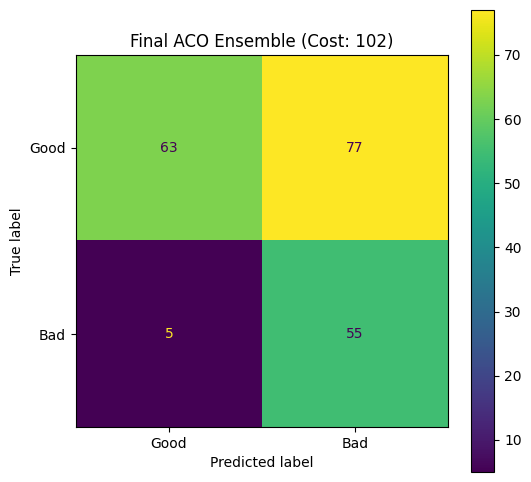

In [17]:
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, binary_aco, ax=ax, display_labels=["Good", "Bad"])
plt.title(f"Final ACO Ensemble (Cost: {test_cost})")
plt.savefig("confusion_matrix.png")
mlflow.log_artifact("confusion_matrix.png")

signature = infer_signature(X_test, pred_aco)

mlflow.log_artifact("credit_risk_model.pkl")

mlflow.end_run()
print(f"MLflow Run finalized: {run.info.run_id}")

# 13.Gradio UI

In [ ]:


import gradio as gr
import joblib
import torch
import numpy as np
import pandas as pd

artifacts = joblib.load('credit_risk_model.pkl')
trained_pipelines = artifacts['trained_pipelines']
w_aco = artifacts['w_aco']
t_aco = artifacts['t_aco']
feature_names = artifacts['feature_names']
numerical_cols = artifacts['numerical_cols']
categorical_cols = artifacts['categorical_cols']
ohe_categories = artifacts['ohe_categories']
numerical_ranges = artifacts['numerical_ranges']


# Define prediction function
def predict_credit_risk(*args):
    input_dict = {name: val for name, val in zip(feature_names, args)}
    df = pd.DataFrame([input_dict])

    for col in numerical_cols:
        df[col] = pd.to_numeric(df[col])

    P = np.zeros((1, len(trained_pipelines)))
    for i, (name, pipeline) in enumerate(trained_pipelines.items()):
        P[0, i] = pipeline.predict_proba(df)[0, 1]

    final_prob = float((P @ w_aco)[0])
    decision = "❌ REJECT" if final_prob >= t_aco else "✅ APPROVE (Low Risk)"

    

    return decision, f"{final_prob:.4f}"

   

inputs = []
for col in feature_names:
    if col in numerical_ranges:
        min_val, max_val = numerical_ranges[col]
        inputs.append(gr.Slider(minimum=min_val, maximum=max_val, step=1 if isinstance(min_val, int) else 0.01, label=col))
    else:
        inputs.append(gr.Dropdown(choices=ohe_categories[col], label=col))

outputs = [
    gr.Textbox(label="Financial Decision"),
    gr.Textbox(label="Risk Probability"),
    
]

demo = gr.Interface(
    fn=predict_credit_risk,
    inputs=inputs,
    outputs=outputs,
    title="🏦 Advanced Credit Risk Analyzer",
    description="Asymmetric Cost-Sensitive Ensemble (ACO) Decision threshold optimized for 5:1 False Negative penalty.",
)

demo.launch(share=True, theme="soft")

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/04/01 22:33:33 [W] [service.go:132] login to server failed: tls: failed to verify certificate: x509: certificate has expired or is not yet valid: current time 2026-04-01T22:33:33+05:30 is after 2026-04-01T07:01:35Z
